# Лабораторная работа 2

1. Показать что функция выпукла и дважды дифференцируема
2. Реализовать алгоритмы оптимизации BFGS и L-BFGS, в которых для каждой воплощены версии, в которых а) используется аналитическое (определите самостоятельно) задание градиента целевой функции, и б) численное, на основе конечных разностей.
3. Реализовать инициализацию приближения матрицы Гессе через произвольную матрицу (например, единичную), и через вычисленные на основе конечных разностей частные производные целевой функции.
4. Реализовать поиск градиента через метод конечных разностей

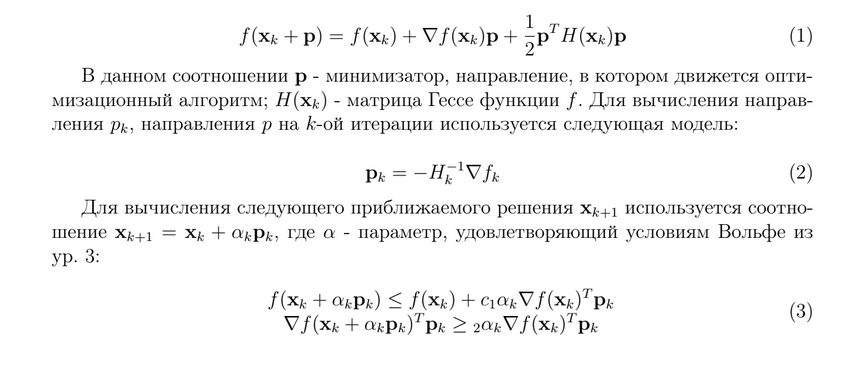
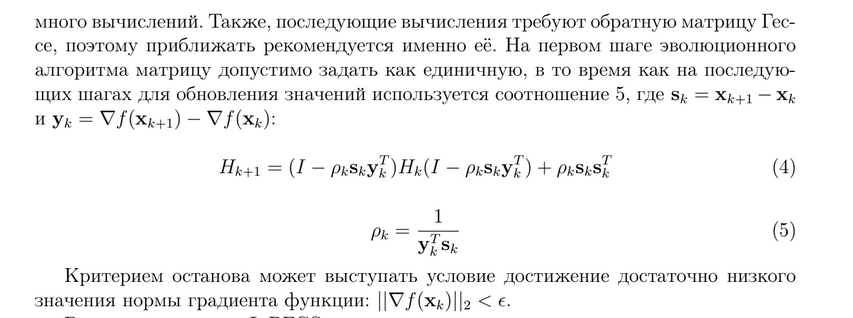

Алгоритм лабораторной:
1. Берем стратовую точку (0, 0) и начальное значение матрицы гессе (Единичная матрица), считаем градиент в этой точке.
2. Считаем направление p по формуле (2)
3. Ищем параметр a (функции `zoom` и `wolf_cond`)
4. Делаем шаг xk+1 = xk + a*p
5. Вычисляем градиент в новой точке xk+1
6. считаем sk и yk над формулой (4)
7. Обновляем матрицу Гессе формула (4)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

def f(x):
    return 0.5 * (x[0]**2 + (x[0]-x[1])**2 + (x[1]-x[2])**2 + x[2]**2) - x[0]

In [3]:
def grad_f(x):
    grad_x0 = 2 * x[0] - x[1] - 1
    grad_x1 = -x[0] + 2 * x[1] - x[2]
    grad_x2 = -x[1] + 2 * x[2]
    return np.array([grad_x0, grad_x1, grad_x2])

In [4]:
def finite_diff_grad_f(x, f=f, h=1e-6):
    '''
    Градиент через конечные разности
    '''
    n = len(x)
    grad = np.zeros(n)
    for i in range(n):
        x_forward = np.array(x, dtype=float)
        x_backward = np.array(x, dtype=float)
        x_forward[i] += h
        x_backward[i] -= h
        grad[i] = (f(x_forward) - f(x_backward)) / (2 * h)
    return grad


In [5]:
def zoom(a_low, a_high, c1, c2, x, p, f, grad_f, max_zoom_iter=100):
    iter = 0
    while iter < max_zoom_iter:
        a = 0.5 * (a_low + a_high)
        value = f(x + a*p)
        if (value > f(x) + c1*a*np.dot(grad_f(x), p)) or (value >= f(x + a_low*p)):
            a_high = a
        else:
            grad_value = grad_f(x + a * p)
            if abs(np.dot(grad_value, p)) <= -c2 * np.dot(grad_f(x), p):
                return a
            if np.dot(grad_value, (a_high - a_low)*p) >= 0:
                a_high = a_low
            a_low = a
        iter += 1
    return a

In [6]:
def line_search(f, grad_f, x, p, c1, c2, alpha_max, max_iter, zoom):

    alpha_0 = 0
    alpha_1 = alpha_max / 2
    i = 1

    while True:
        xi = x + alpha_1 * p
        f_xi = f(xi)
        if f_xi > f(x) + c1 * alpha_1 * np.dot(grad_f(x), p) or (i > 1 and f_xi >= f(x + alpha_0 * p)):
            return zoom(alpha_0, alpha_1, c1, c2, x, p, f, grad_f)
        grad_f_xi = grad_f(xi)
        if np.linalg.norm(grad_f_xi) <= -c2 * np.linalg.norm(grad_f(x)):
            return alpha_1
        if np.dot(grad_f_xi, p) >= 0:
            return zoom(alpha_0, alpha_1, c1, c2, x, p, f, grad_f)
        alpha_0 = alpha_1
        alpha_1 = (alpha_1 + alpha_max) / 2
        i += 1
        if i > max_iter:  # условие остановки по итерациям
            return alpha_1


Я хз как оформить, на листке расписал

Провери дважды дифференцируемость и выпуклость целевой функции $$f(x)=\frac{1}{2}[(x_1)^2+(x_1-x_2)^2+(x_2-x_3)^2+x_3^2]-x_1$$
Вычислим первые частные производные
$$\frac{df}{dx_1}=\frac{1}{2}[2x_1+2(x_1-x_2)]-1 = 2x_1-x_2-1$$
$$ \frac{df}{dx_2} = -(x_1-x_2)+(x_2-x_3) = -x_1+2x_2-x_3$$
$$ \frac{df}{dx_3} = -(x_2-x_3)+x_3 = -x_2+2x_3 $$

Вычислим смешанные производные:
$$ \frac{d^2f}{dx_1 dx_2} = -1$$
$$ \frac{d^2f}{dx_1 dx_3} = 0$$
$$ \frac{d^2f}{dx_2 dx_3} = -1$$

Вычислим вторые частные производные
$$ \frac{d^2f}{dx_1^2} = 2 $$
$$ \frac{d^2f}{dx_2^2} = 2 $$
$$ \frac{d^2f}{dx_3^2} = 2 $$

Частные производные определены => целевая функция дважды дифференцируема. Состами гессиан данной функции
$$
H = \begin{pmatrix}
2 & -1 & 0 \\
-1 & 2 & -1 \\
0 & -1 & 2
\end{pmatrix}
$$
Данная матирца положительно определена => целевая функция выпукла




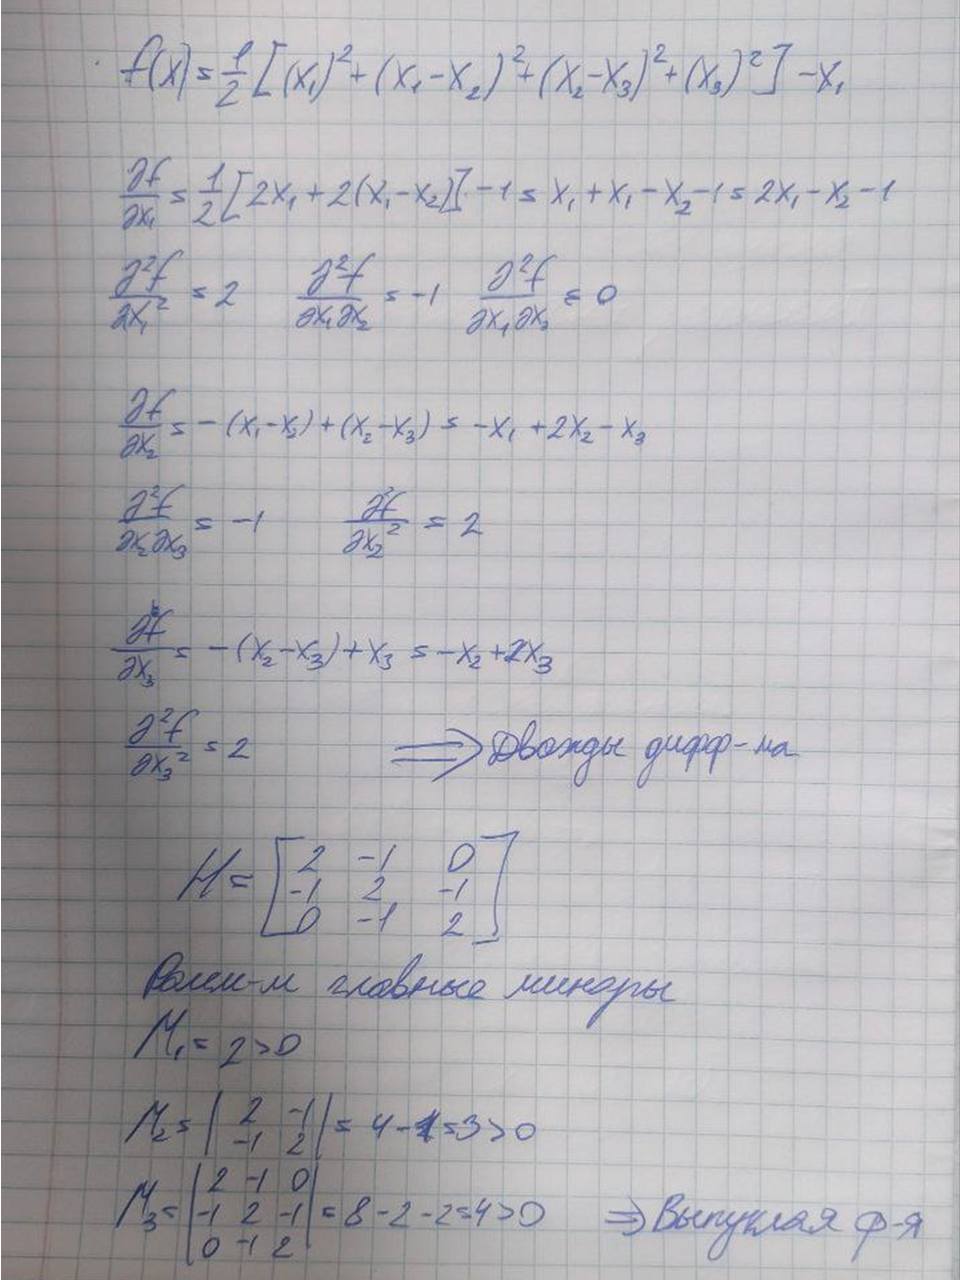

# BFGS

In [7]:
def bfgs(f, grad_f, x0, epsilon, c1, c2, alpha_max, max_ls_iter, max_iter):
    '''
    Аргументы:
        f: Целевая функция для минимизации.
        grad_f: Градиент целевой функции.
        x0: Начальное приближение для минимума.
        epsilon: Допуск для нормы градиента для остановки алгоритма.
        c1: Константа для условия Вульфа 1.
        c2: Константа для условия Вульфа 2.
        alpha_max: Максимальный размер шага для поиска линии.
        max_ls_iter: Максимальное количество итераций для поиска линии.
        max_iter: Максимальное количество итераций для алгоритма BFGS.
    '''
    x_k = np.array(x0, dtype=float)
    n = len(x_k)
    H_k = np.eye(n)  # Инициализация обратной матрицы Гессе как единичной матрицы
    k = 0

    while np.linalg.norm(grad_f(x_k)) >= epsilon and k < max_iter:
        p_k = -H_k @ grad_f(x_k)  # Направление поиска

        # Выполнение поиска линии для нахождения оптимального размера шага alpha_k
        alpha_k = line_search(f, grad_f, x_k, p_k, c1, c2, alpha_max, max_ls_iter, zoom)

        s_k = alpha_k * p_k
        x_k_plus_1 = x_k + s_k
        y_k = grad_f(x_k_plus_1) - grad_f(x_k)

        rho_k = 1 / np.dot(y_k, s_k)
        I = np.eye(n)

        H_k = (I - rho_k * np.outer(s_k, y_k)) @ H_k @ (I - rho_k * np.outer(y_k, s_k)) + rho_k * np.outer(s_k, s_k)

        x_k = x_k_plus_1
        k += 1
        print(f"Iteration {k}:, f(x) = {f(x_k)}, ||grad_f(x)|| = {np.linalg.norm(grad_f(x_k))}")
    print(x_k)
    return x_k, f(x_k)

In [8]:
x0 = [100, 120, 150]
epsilon = 1e-6
c1 = 1e-3
c2 = 0.95
alpha_max = 1.0
max_ls_iter = 100
max_iter = 1000

optimal_x, optimal_f = bfgs(f, grad_f, x0, epsilon, c1, c2, alpha_max, max_ls_iter, max_iter)
print("\nОтвет x:", optimal_x)
print("Значение функции в точке x:", optimal_f)

Iteration 1:, f(x) = 9697.9375, ||grad_f(x)|| = 112.22883987638828
Iteration 2:, f(x) = 966.950538276737, ||grad_f(x)|| = 59.178158627820046
Iteration 3:, f(x) = 14.799133015709911, ||grad_f(x)|| = 10.034380986344912
Iteration 4:, f(x) = -0.364037694432988, ||grad_f(x)|| = 0.26303398007623185
Iteration 5:, f(x) = -0.37499999988299226, ||grad_f(x)|| = 1.8962530153903324e-05
Iteration 6:, f(x) = -0.3749999999999999, ||grad_f(x)|| = 2.1859361129954452e-08
[0.75000001 0.50000001 0.25      ]

Ответ x: [0.75000001 0.50000001 0.25      ]
Значение функции в точке x: -0.3749999999999999


# L-BFGS

http://www.machinelearning.ru/wiki/images/6/63/MO17_practice2.pdf

In [9]:
def l_bfgs(f, grad_f, x0, epsilon, c1, c2, alpha_max, max_ls_iter, max_iter, m=10):
    '''
    Аргументы:
        f: Целевая функция для минимизации.
        grad_f: Градиент целевой функции.
        x0: Начальное приближение для минимума.
        epsilon: Допуск для нормы градиента для остановки алгоритма.
        c1: Константа для условия Вульфа 1.
        c2: Константа для условия Вульфа 2.
        alpha_max: Максимальный размер шага для поиска линии.
        max_ls_iter: Максимальное количество итераций для поиска линии.
        max_iter: Максимальное количество итераций для алгоритма L-BFGS.
        m: Количество пар (s_k, y_k) для хранения (размер памяти).
    '''
    x_k = np.array(x0, dtype=float)
    n = len(x_k)
    s_history = []
    y_history = []
    k = 0

    while np.linalg.norm(grad_f(x_k)) >= epsilon and k < max_iter:
        grad_k = grad_f(x_k)

        # Вычисление направления поиска p_k
        if k == 0:
            p_k = -grad_k
        else:
            q = np.array(grad_k)
            alpha = []
            for i in range(len(s_history) - 1, -1, -1):
                s_i = s_history[i]
                y_i = y_history[i]
                rho_i = 1.0 / np.dot(y_i, s_i)
                alpha_i = rho_i * np.dot(s_i, q)
                alpha.append(alpha_i)
                q = q - alpha_i * y_i


            gamma_k = np.dot(s_history[-1], y_history[-1]) / np.dot(y_history[-1], y_history[-1]) if s_history else 1.0
            Hk0 = gamma_k * np.eye(n)
            r = Hk0 @ q
            for i in range(len(s_history)):
                s_i = s_history[i]
                y_i = y_history[i]
                dot_ys = np.dot(y_i, s_i)
                if abs(dot_ys) < 1e-12:
                    dot_ys = np.sign(dot_ys) * 1e-12 if dot_ys != 0 else 1e-12

                rho_i = 1.0 / dot_ys

                beta_i = rho_i * np.dot(y_i, r)
                r = r + s_i * (alpha[len(s_history) - 1 - i] - beta_i)

            p_k = -r

        # Выполнение поиска линии для нахождения оптимального размера шага alpha_k
        alpha_k = line_search(f, grad_f, x_k, p_k, c1, c2, alpha_max, max_ls_iter, zoom)

        s_k = alpha_k * p_k
        x_k_plus_1 = x_k + s_k
        y_k = grad_f(x_k_plus_1) - grad_f(x_k)

        # Обновление истории s и y
        s_history.append(s_k)
        y_history.append(y_k)

        # Ограничиваем размер истории до m
        if len(s_history) > m:
            s_history.pop(0) # Удаляем старый элемент из начала
            y_history.pop(0) # Удаляем старый элемент из начала


        x_k = x_k_plus_1
        k += 1
        print(f"Iteration {k}, f(x) = {f(x_k)}, ||grad_f(x)|| = {np.linalg.norm(grad_f(x_k))}")
    print(x_k)
    return x_k, f(x_k)

In [10]:
x0 = [100, 120, 150]
epsilon = 1e-6
c1 = 1e-3
c2 = 0.95
alpha_max = 1.0
max_ls_iter = 100
max_iter = 1000
m = 10 # Размер памяти для L-BFGS

optimal_x_lbfgs, optimal_f_lbfgs = l_bfgs(f, finite_diff_grad_f, x0, epsilon, c1, c2, alpha_max, max_ls_iter, max_iter, m)
print("\nОтвет x:", optimal_x_lbfgs)
print("Значение функции в точке x:", optimal_f_lbfgs)

Iteration 1, f(x) = 9697.937521115076, ||grad_f(x)|| = 112.22883913510232
Iteration 2, f(x) = 3660.805872873398, ||grad_f(x)|| = 79.33713181100627
Iteration 3, f(x) = 358.2828369236995, ||grad_f(x)|| = 36.256699182185855
Iteration 4, f(x) = 7.551298716935973, ||grad_f(x)|| = 6.057726352580736
Iteration 5, f(x) = -0.2964352687935887, ||grad_f(x)|| = 0.359549527814887
Iteration 6, f(x) = -0.3743920839612365, ||grad_f(x)|| = 0.04720123354764505
Iteration 7, f(x) = -0.37499990251118054, ||grad_f(x)|| = 0.0006564770025379794
Iteration 8, f(x) = -0.37499999999144035, ||grad_f(x)|| = 5.9481915589118176e-06
Iteration 9, f(x) = -0.37499999999999756, ||grad_f(x)|| = 9.903052856755705e-08
[0.75000003 0.50000006 0.25000001]

Ответ x: [0.75000003 0.50000006 0.25000001]
Значение функции в точке x: -0.37499999999999756


# 2 Часть

## Adam

In [11]:
def adam_fd(f, x0, alpha=0.01, beta1=0.9, beta2=0.999, epsilon=1e-8, h=1e-6, max_iter=1000, tol=1e-6, verbose=True):

    x = np.array(x0, dtype=float)
    m = np.zeros_like(x)
    v = np.zeros_like(x)
    t = 0

    for t in range(1, max_iter + 1):
        g = finite_diff_grad_f(x, f, h)

        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * (g ** 2)

        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)

        x = x - alpha * m_hat / (np.sqrt(v_hat) + epsilon)

        if verbose and t % 50 == 0:
            print(f"Iter {t}: f(x)={f(x):.6f}, ||grad||={np.linalg.norm(g):.6e}")

        if np.linalg.norm(g) < tol:
            break

    return x, f(x)

## Приминение методов оптимизации на данных из 1 лабораторной

In [12]:
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

In [13]:
X, y = load_wine(return_X_y=True)

X = np.hstack([X, np.ones((X.shape[0], 1))])

n_samples, n_features = X.shape
n_classes = len(np.unique(y))
Y = np.zeros((n_samples, n_classes))
Y[np.arange(n_samples), y] = 1

In [14]:
def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def log_loss(w_flat):
    W = w_flat.reshape(n_features, n_classes)
    P = softmax(X @ W)
    loss = -np.sum(Y * np.log(P + 1e-12)) / len(X)
    return loss

def grad_log_loss(w_flat):
    W = w_flat.reshape(n_features, n_classes)
    P = softmax(X @ W)
    grad = X.T @ (P - Y) / len(X)
    return grad.flatten()

## bfgs

In [15]:
x0 = np.zeros(n_features * n_classes)
epsilon = 1e-6
c1 = 1e-3
c2 = 0.95
alpha_max = 1.0
max_ls_iter = 100
max_iter = 50

optimal_x, optimal_f = bfgs(log_loss, grad_log_loss, x0, epsilon, c1, c2, alpha_max, max_ls_iter, max_iter)
print("\nОтвет x:", optimal_x)
print("Значение функции в точке x:", optimal_f)
W_opt_bfgs = optimal_x.reshape(n_features, n_classes)

Iteration 1:, f(x) = 1.078322946366207, ||grad_f(x)|| = 117.84720336819171
Iteration 2:, f(x) = 1.0755877933102669, ||grad_f(x)|| = 105.18835897274977
Iteration 3:, f(x) = 0.7890072167972697, ||grad_f(x)|| = 131.9061427281792
Iteration 4:, f(x) = 0.7027245711680221, ||grad_f(x)|| = 50.22622892213562
Iteration 5:, f(x) = 0.1995461341599052, ||grad_f(x)|| = 13.232690906851593
Iteration 6:, f(x) = 0.17816327339946555, ||grad_f(x)|| = 23.378483174577056
Iteration 7:, f(x) = 0.15479217497487713, ||grad_f(x)|| = 16.966819788634975
Iteration 8:, f(x) = 0.1281280995554809, ||grad_f(x)|| = 15.614608495603365
Iteration 9:, f(x) = 0.09505933640446584, ||grad_f(x)|| = 8.250844754627302
Iteration 10:, f(x) = 0.08667679494811892, ||grad_f(x)|| = 12.454577254362736
Iteration 11:, f(x) = 0.08250276678827112, ||grad_f(x)|| = 13.439583519211673
Iteration 12:, f(x) = 0.0748488752494305, ||grad_f(x)|| = 10.540880681319017
Iteration 13:, f(x) = 0.06950281224363031, ||grad_f(x)|| = 5.321239555098725
Iterati

## L-bfgs

In [16]:
x0 = np.zeros(n_features * n_classes)
epsilon = 1e-6
c1 = 1e-3
c2 = 0.95
alpha_max = 1.0
max_ls_iter = 100
max_iter = 50
m = 10

fin_grad_log_loss = lambda w: finite_diff_grad_f(w, log_loss)

optimal_x_lbfgs, optimal_f_lbfgs = l_bfgs(log_loss, fin_grad_log_loss, x0, epsilon, c1, c2, alpha_max, max_ls_iter, max_iter, m)
W_opt_lbfgs = optimal_x_lbfgs.reshape(n_features, n_classes)

Iteration 1, f(x) = 1.0783229463658297, ||grad_f(x)|| = 117.84718955909271
Iteration 2, f(x) = 1.048125375181404, ||grad_f(x)|| = 16.714122088046
Iteration 3, f(x) = 1.0469291507075476, ||grad_f(x)|| = 16.01120841879788
Iteration 4, f(x) = 1.0314652016294632, ||grad_f(x)|| = 49.075246926965285
Iteration 5, f(x) = 1.0046392683978191, ||grad_f(x)|| = 92.41291187597749
Iteration 6, f(x) = 0.9375812530313732, ||grad_f(x)|| = 143.6582144294474
Iteration 7, f(x) = 0.8362183285913231, ||grad_f(x)|| = 148.68118917967135
Iteration 8, f(x) = 0.833845502125515, ||grad_f(x)|| = 151.5118987438949
Iteration 9, f(x) = 0.7405925105222512, ||grad_f(x)|| = 103.1155121407502
Iteration 10, f(x) = 0.6885372753704253, ||grad_f(x)|| = 63.55135886396489
Iteration 11, f(x) = 0.6601309848153205, ||grad_f(x)|| = 33.01838962849395
Iteration 12, f(x) = 0.6497575460739305, ||grad_f(x)|| = 14.247163868655521
Iteration 13, f(x) = 0.647461495942521, ||grad_f(x)|| = 4.592626423687494
Iteration 14, f(x) = 0.647189779156

## Adam

In [17]:
x0 = np.zeros(n_features * n_classes)


optimal_x_adam, optimal_f_adam = adam_fd(log_loss, x0)
W_opt_adam = optimal_x_lbfgs.reshape(n_features, n_classes)

Iter 50: f(x)=0.362832, ||grad||=3.592923e+01
Iter 100: f(x)=0.237496, ||grad||=7.868594e-01
Iter 150: f(x)=0.186905, ||grad||=5.251210e-01
Iter 200: f(x)=0.159195, ||grad||=2.416072e-01
Iter 250: f(x)=0.141932, ||grad||=1.208096e-01
Iter 300: f(x)=0.129557, ||grad||=8.945272e-02
Iter 350: f(x)=0.120030, ||grad||=7.499070e-02
Iter 400: f(x)=0.112385, ||grad||=6.516744e-02
Iter 450: f(x)=0.106055, ||grad||=5.772418e-02
Iter 500: f(x)=0.100678, ||grad||=5.183445e-02
Iter 550: f(x)=0.096014, ||grad||=4.704200e-02
Iter 600: f(x)=0.091896, ||grad||=4.306190e-02
Iter 650: f(x)=0.088207, ||grad||=3.970404e-02
Iter 700: f(x)=0.084864, ||grad||=3.683442e-02
Iter 750: f(x)=0.081802, ||grad||=3.435425e-02
Iter 800: f(x)=0.078976, ||grad||=3.218839e-02
Iter 850: f(x)=0.076350, ||grad||=3.027851e-02
Iter 900: f(x)=0.073895, ||grad||=2.857883e-02
Iter 950: f(x)=0.071590, ||grad||=2.705317e-02
Iter 1000: f(x)=0.069417, ||grad||=2.567285e-02


## Сравнение

In [18]:
y_pred = np.argmax(softmax(X @ W_opt_bfgs), axis=1)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       1.00      1.00      1.00        71
           2       1.00      1.00      1.00        48

    accuracy                           1.00       178
   macro avg       1.00      1.00      1.00       178
weighted avg       1.00      1.00      1.00       178



In [19]:
y_pred = np.argmax(softmax(X @ W_opt_lbfgs), axis=1)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        59
           1       0.93      0.92      0.92        71
           2       0.96      0.98      0.97        48

    accuracy                           0.94       178
   macro avg       0.94      0.94      0.94       178
weighted avg       0.94      0.94      0.94       178



In [20]:
y_pred = np.argmax(softmax(X @ W_opt_adam), axis=1)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        59
           1       0.93      0.92      0.92        71
           2       0.96      0.98      0.97        48

    accuracy                           0.94       178
   macro avg       0.94      0.94      0.94       178
weighted avg       0.94      0.94      0.94       178



In [21]:
etalon = LogisticRegression(max_iter=100)
etalon.fit(X, y)
print(classification_report(y, etalon.predict(X)))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97        59
           1       0.95      0.97      0.96        71
           2       0.96      0.98      0.97        48

    accuracy                           0.97       178
   macro avg       0.97      0.97      0.97       178
weighted avg       0.97      0.97      0.97       178



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
